<a href="https://colab.research.google.com/github/pritthwishGC/AIML-Lab-Sem-5/blob/main/Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

BFS Traversal Order: A -> B -> C -> D -> E -> F
DFS Traversal Order: A -> B -> D -> E -> C -> F


<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2419/3764608840.py:8: SyntaxWarning: invalid escape sequence '\ '
  / \ \


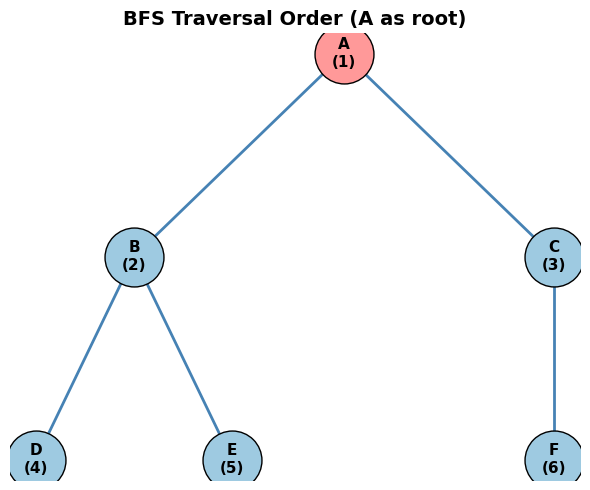

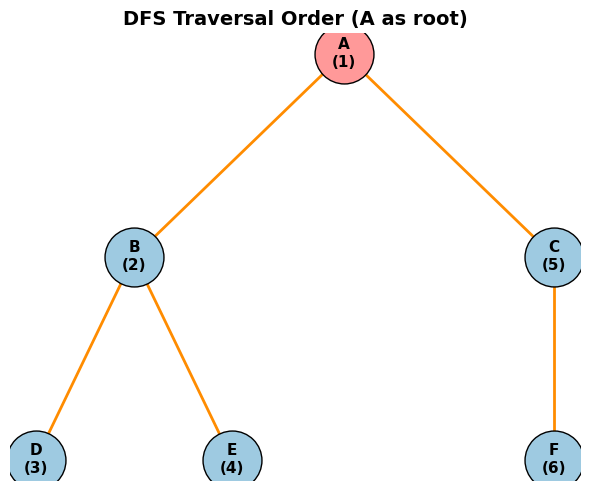

In [3]:
"""
Problem 1: BFS and DFS Traversal of a Graph
Tree with 6 nodes (A as root):

        A
      / \
     B C
    / \ \
   D E F

Uses only Python's built-in collections + matplotlib (no networkx needed).
"""

from collections import deque
import matplotlib.pyplot as plt

# 1. Adjacency list representation of the graph
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B'],
    'F': ['C']
}

# 2. BFS traversal using a queue
def bfs(graph, start):
    visited = {start}
    order = []
    queue = deque([start])
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return order

# 3. DFS traversal using recursion
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()
        order = []
    visited.add(start)
    order.append(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, order)
    return order

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal Order:", " -> ".join(bfs_order))
print("DFS Traversal Order:", " -> ".join(dfs_order))

# 4. Draw the tree using plain matplotlib (manual node positions + line segments)
edges = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F')]

pos = {
    'A': (0, 3),
    'B': (-1.5, 2),
    'C': (1.5, 2),
    'D': (-2.2, 1),
    'E': (-0.8, 1),
    'F': (1.5, 1)
}

def draw_traversal(order, title, edge_color):
    fig, ax = plt.subplots(figsize=(6, 5))

    # Draw edges as line segments
    for (u, v) in edges:
        x_vals = [pos[u][0], pos[v][0]]
        y_vals = [pos[u][1], pos[v][1]]
        ax.plot(x_vals, y_vals, color=edge_color, linewidth=2, zorder=1)

    # Draw nodes as circles with visit-order labels
    rank = {node: i + 1 for i, node in enumerate(order)}
    for node, (x, y) in pos.items():
        face_color = '#ff9999' if node == order[0] else '#9ecae1'
        ax.scatter(x, y, s=1800, color=face_color, edgecolors='black', zorder=2)
        ax.text(x, y, f"{node}\n({rank[node]})", ha='center', va='center',
                fontsize=11, fontweight='bold', zorder=3)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_traversal(bfs_order, "BFS Traversal Order (A as root)", edge_color='steelblue')
draw_traversal(dfs_order, "DFS Traversal Order (A as root)", edge_color='darkorange')